In [1]:
%load_ext autoreload
%autoreload 2

import torch, json, time, numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import defaultdict
from tqdm import tqdm

import torch_svd as tsvd  # uses optimized SVD utilities

torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if hasattr(torch.backends,'mps') and torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

# Memory helpers
def gpu_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated()/1024**2
    return 0.0

def gpu_peak_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated()/1024**2
    return 0.0

def gpu_reset_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

# Device sync utility for timing
def _sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elif hasattr(torch.backends,'mps') and torch.backends.mps.is_available():
        torch.mps.synchronize()

Using device: cuda


In [2]:
# CIFAR-10 dataset & config
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])

train_dataset = datasets.CIFAR10(root='./datasets', train=True, download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10(root='./datasets', train=False, download=True, transform=transform_test)

batch_size = 512              # reduce to mitigate Jacobian memory
input_dim  = 32*32*3
hidden_dims = [512, 256, 128]  # MLP size
num_classes = 10
num_epochs = 3
print(f"Input dim {input_dim}, hidden {hidden_dims}, classes {num_classes}")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

Input dim 3072, hidden [512, 256, 128], classes 10


In [5]:
# Normal MLP supervised training
model_sup = tsvd.MLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=num_classes).to(device)
print(f"Supervised MLP params: {sum(p.numel() for p in model_sup.parameters())}")
optimizer = torch.optim.Adam(model_sup.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

losses_direct = defaultdict(list)
mem_direct = defaultdict(list)  # peak per batch

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    epoch_losses = defaultdict(list)
    model_sup.train()
    for xb, yb in tqdm(train_loader, desc="Train MLP"):
        xb = xb.view(xb.size(0), -1).to(device)
        yb = yb.to(device)
        gpu_reset_peak()
        optimizer.zero_grad(set_to_none=True)
        _sync(); t0 = time.perf_counter()
        ypred = model_sup(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        _sync(); mem_direct['step_time'].append(time.perf_counter()-t0)
        epoch_losses['train'].append(loss.item())
        mem_direct['train_peak_mb'].append(gpu_peak_mb())
    
    model_sup.eval()
    with torch.no_grad():
        correct=0; total=0
        for xb, yb in tqdm(test_loader, desc="Val MLP"):
            xb = xb.view(xb.size(0), -1).to(device)
            yb = yb.to(device)
            ypred = model_sup(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
            _, pred = ypred.max(1)
            total += yb.size(0)
            correct += pred.eq(yb).sum().item()
    acc = 100.*correct/total
    print(f"Val Acc: {acc:.2f}%")
    losses_direct['train_batch'].extend(epoch_losses['train'])
    losses_direct['val_batch'].extend(epoch_losses['val'])
    for k,v in epoch_losses.items():
        losses_direct[k].append(np.mean(v))
    print(f"Train Loss {losses_direct['train'][-1]:.4f}  Val Loss {losses_direct['val'][-1]:.4f}  Peak MB(avg): {np.mean(mem_direct['train_peak_mb'][-len(train_loader):]):.1f}")

with open('cifar10_mlp_direct_losses.json','w') as f:
    json.dump({k:v for k,v in losses_direct.items()}, f)


Supervised MLP params: 1738890
Epoch 1/3


Val MLP: 100%|██████████| 40/40 [00:00<00:00, 41.68it/s]


Val Acc: 41.43%
Train Loss 1.8210  Val Loss 1.6308  Peak MB(avg): 74.7
Epoch 2/3


Val MLP: 100%|██████████| 40/40 [00:00<00:00, 42.13it/s]


Val Acc: 44.73%
Train Loss 1.6256  Val Loss 1.5422  Peak MB(avg): 74.7
Epoch 3/3


Val MLP: 100%|██████████| 40/40 [00:00<00:00, 50.25it/s]

Val Acc: 45.13%
Train Loss 1.5492  Val Loss 1.5133  Peak MB(avg): 74.7


In [ ]:
# SVD-based training with FunctionalModelJac
model_svd = tsvd.MLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=num_classes).to(device)
print(f"SVD MLP params: {sum(p.numel() for p in model_svd.parameters())}")

loss_fn_svd = nn.CrossEntropyLoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn_svd(pred, y).squeeze()

# Limit k to mitigate memory usage
k_svd = batch_size
rtol = 1e-3
lr_svd = 0.1
opt_svd = tsvd.SVDOptimizer(lr=lr_svd, k=k_svd, rtol=rtol)

fmodel_svd = tsvd.FunctionalModelJac(model_svd, loss_lambda, opt_svd)

train_loader_svd = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True, pin_memory=torch.cuda.is_available())
test_loader_svd  = test_loader  # reuse

losses_svd = defaultdict(list)
batch_losses_svd = defaultdict(list)
mem_svd = defaultdict(list)

for epoch in range(num_epochs):
    print(f"Epoch (SVD) {epoch+1}/{num_epochs}")
    epoch_losses = defaultdict(list)
    for b_idx, (xb, yb) in enumerate(tqdm(train_loader_svd, desc="Train SVD")):
        xb = xb.view(xb.size(0), -1).to(device)
        yb = yb.to(device)
        batch = (xb, yb)
        gpu_reset_peak()
        # run train step with memory tracking
        losses, extras = fmodel_svd.train_step(batch, track_memory=True)
        epoch_losses['train'].append(losses.mean().item())
        batch_losses_svd['train'].append(losses.mean().cpu().numpy())
        # record singular value info
        if 'singular_values' in extras:
            batch_losses_svd['train_singular_values'].append(extras['singular_values'])
        if 'num_svs' in extras:
            batch_losses_svd['train_num_svs'].append(extras['num_svs'])
        # memory stats
        mem_track = extras.get('memory', {})
        for k,v in mem_track.items():
            mem_svd.setdefault(k, []).append(v)
        mem_svd.setdefault('peak_mb', []).append(gpu_peak_mb())
        if b_idx % 10 == 0:
            peak_now = mem_svd['peak_mb'][-1]
            print(f"  Batch {b_idx} peak {peak_now:.1f} MB")
    # validation
    correct=0; total=0
    with torch.no_grad():
        for xb, yb in tqdm(test_loader_svd, desc="Val SVD"):
            xb = xb.view(xb.size(0), -1).to(device)
            yb = yb.to(device)
            ypred = fmodel_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
            _, pred = ypred.max(1)
            total += yb.size(0)
            correct += pred.eq(yb).sum().item()
    acc = 100.*correct/total
    losses_svd['train_batch'].extend(epoch_losses['train'])
    losses_svd['val_batch'].extend(epoch_losses['val'])
    for k,v in epoch_losses.items():
        losses_svd[k].append(np.mean(v))
    print(f"SVD Train Loss {losses_svd['train'][-1]:.4f}  Val Loss {losses_svd['val'][-1]:.4f}  Val Acc {acc:.2f}%")

with open('cifar10_mlp_svd_losses.json','w') as f:
    json.dump({k:v for k,v in losses_svd.items()}, f)


SVD MLP params: 1738890
Epoch (SVD) 1/3


Train SVD:   0%|          | 0/97 [00:00<?, ?it/s]

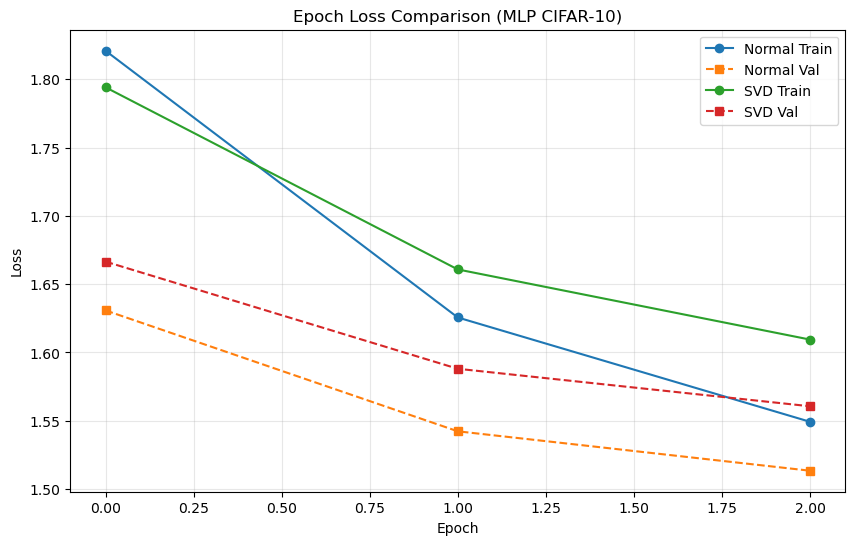

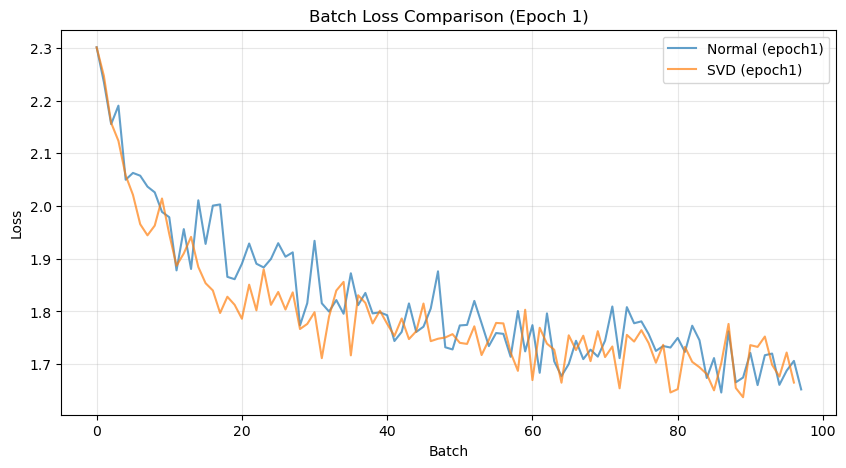

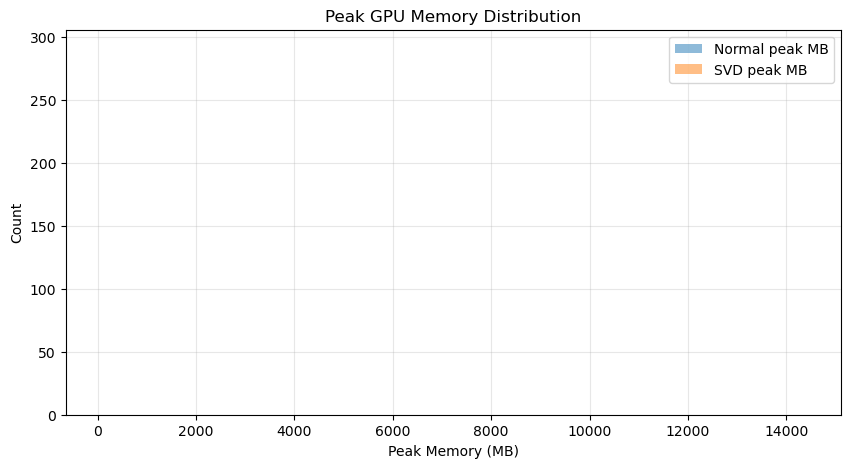

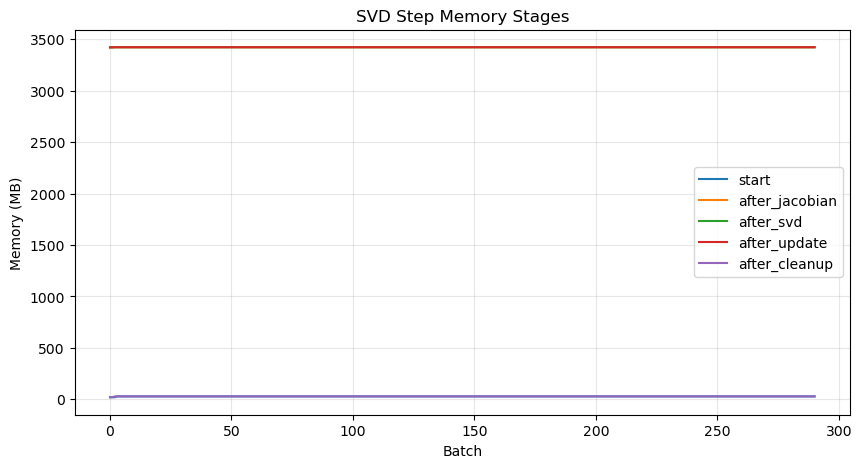

In [6]:
# Analysis plots: epoch losses
plt.figure(figsize=(10,6))
plt.plot(losses_direct['train'], label='Normal Train', marker='o')
plt.plot(losses_direct['val'], label='Normal Val', marker='s', linestyle='--')
plt.plot(losses_svd['train'], label='SVD Train', marker='o')
plt.plot(losses_svd['val'], label='SVD Val', marker='s', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Epoch Loss Comparison (MLP CIFAR-10)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Batch-level first epoch comparison
n_batches_direct = len(losses_direct['train_batch'])//num_epochs
n_batches_svd    = len(losses_svd['train_batch'])//num_epochs
plt.figure(figsize=(10,5))
plt.plot(losses_direct['train_batch'][:n_batches_direct], label='Normal (epoch1)', alpha=0.7)
plt.plot(losses_svd['train_batch'][:n_batches_svd], label='SVD (epoch1)', alpha=0.7)
plt.xlabel('Batch'); plt.ylabel('Loss'); plt.title('Batch Loss Comparison (Epoch 1)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Memory usage distribution (peak per batch)
plt.figure(figsize=(10,5))
plt.hist(mem_direct['train_peak_mb'], bins=40, alpha=0.5, label='Normal peak MB')
if 'peak_mb' in mem_svd:
    plt.hist(mem_svd['peak_mb'], bins=40, alpha=0.5, label='SVD peak MB')
plt.xlabel('Peak Memory (MB)'); plt.ylabel('Count'); plt.title('Peak GPU Memory Distribution')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Memory evolution over SVD batches
if 'after_jacobian' in mem_svd:
    plt.figure(figsize=(10,5))
    plt.plot(mem_svd['start'], label='start')
    plt.plot(mem_svd['after_jacobian'], label='after_jacobian')
    plt.plot(mem_svd['after_svd'], label='after_svd')
    plt.plot(mem_svd['after_update'], label='after_update')
    plt.plot(mem_svd['after_cleanup'], label='after_cleanup')
    plt.xlabel('Batch'); plt.ylabel('Memory (MB)'); plt.title('SVD Step Memory Stages')
    plt.legend(); plt.grid(alpha=0.3); plt.show()


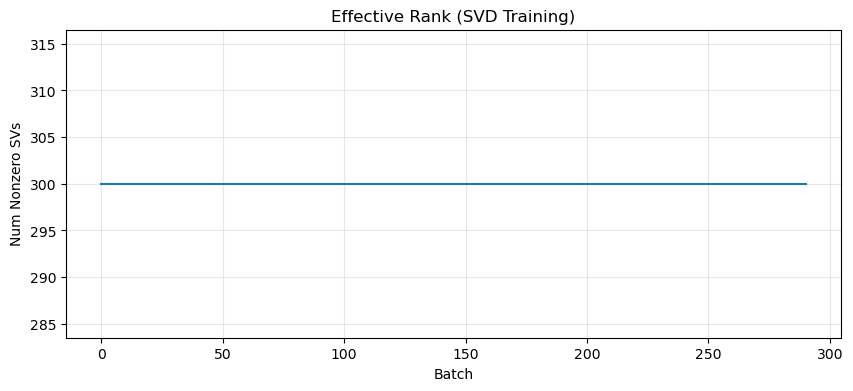

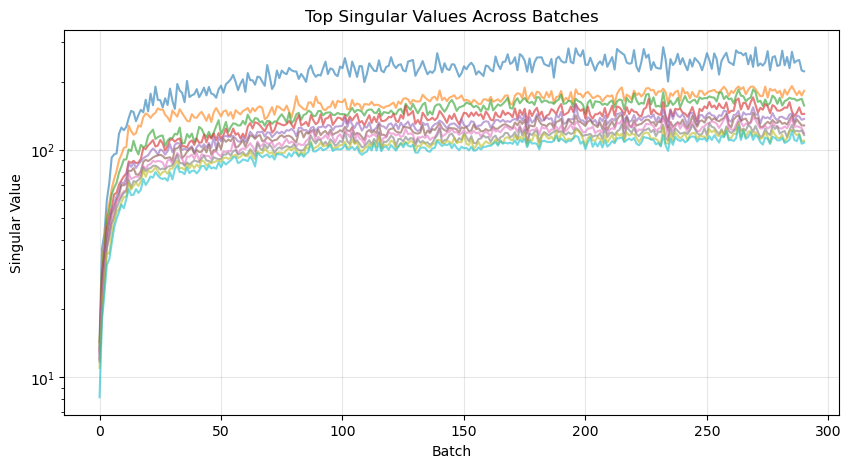

In [7]:
# Singular value diagnostics
if 'train_num_svs' in batch_losses_svd:
    plt.figure(figsize=(10,4))
    plt.plot(batch_losses_svd['train_num_svs'])
    plt.xlabel('Batch'); plt.ylabel('Num Nonzero SVs'); plt.title('Effective Rank (SVD Training)'); plt.grid(alpha=0.3)
    plt.show()

if 'train_singular_values' in batch_losses_svd:
    n_batches = len(batch_losses_svd['train_singular_values'])
    # Plot first 10 singular value trajectories (log scale)
    plt.figure(figsize=(10,5))
    for i in range(min(10, k_svd)):
        traj = [svs[i] if i < len(svs) else 0 for svs in batch_losses_svd['train_singular_values']]
        plt.plot(traj, alpha=0.6)
    plt.xlabel('Batch'); plt.ylabel('Singular Value'); plt.yscale('log'); plt.title('Top Singular Values Across Batches')
    plt.grid(alpha=0.3)
    plt.show()

# Summary & Next Steps

**Notebook Goals**
- Compare standard MLP training vs SVD-based parameter updates on CIFAR-10.
- Track GPU memory consumption at each stage of the SVD `train_step`.
- Inspect effective Jacobian rank (nonzero singular values) and singular value spectra.

**Implemented Optimizations**
- Limited batch size to 512 (was 1024) to reduce activation + Jacobian memory pressure.
- Limited SVD rank `k` to `min(batch_size, 300)` to avoid forming very large intermediate matrices.
- `FunctionalModelJac` now returns memory stats per stage: start, after_jacobian, after_svd, after_update, after_cleanup.
- Pseudo-inverse path avoids constructing the full `B x P` Jacobian inverse; uses factorized components directly.
- Fused & compiled update operations for speed (`torch.compile`).

**Diagnosing OOM Differences (ResNet vs MLP)**
- Convolutional feature maps retain large spatial activations across layers → higher transient memory than flattened MLP layers.
- Per-sample Jacobian extraction (`jacrev` over batch) magnifies activation lifetime costs.
- Parameter count alone does not determine memory; activation volume × batch size is critical.

**Suggested Further Experiments**
1. Micro-batch Jacobian: split batch into chunks (e.g. 128) and accumulate rows.
2. Mixed precision: enable `torch.cuda.amp.autocast()` for forward & SVD computations.
3. Random projections: approximate J via `J @ R` with low-dimensional R then recover low-rank structure (memory-friendly).
4. Dynamic k: shrink k if singular values decay quickly; adapt per batch.
5. Activation checkpointing: trade compute for memory in ResNet version.

**Next Actions (Optional)**
- Implement micro-batch Jacobian builder.
- Add AMP support to both loops.
- Add randomized projection Jacobian approximation.

Let me know which of these you’d like to prioritize and I can implement them next.
